# Q1. Data Understanding
### What types of data are used in the paper to predict stock market movements, and how are technical indicators derived from this data?
Base data: Daily OHLCV for three ETFs—iShares MSCI Chile (ECH), iShares MSCI Brazil (EWZ), and iShares Core S&P 500 (IVV)—downloaded from Yahoo Finance for **Dec 12, 2009** to **Jan 1, 2020**. The raw fields are **Open, High, Low, Close, Adjusted Close, Volume.**
From these series, the authors generate about 210 technical indicators using the pandas-ta library. After appending the six raw variables, the dataset contains 216 features per ETF.
Each indicator is a deterministic transformation of OHLCV—e.g., moving averages, RSI, MACD, Bollinger Bands, ATR, On-Balance Volume, etc.—computed with varying look-backs. All features are min–max normalized and rows with missing values from indicator look-backs are dropped (Sec. 2.6).

### Discuss the importance of using such indicators in forecasting stock price trends.
Technical indicators condense noisy price/volume data into engineered signals that reveal trend persistence, momentum reversals, volatility regimes, and volume–price imbalances. They provide richer inputs to machine-learning models and, when optimized through feature selection, improve forecasting accuracy and reduce computation cost (≈ +2 pp accuracy with ≈ 5 % of features retained)

# Q2. Security Understanding
Pick one of the 3 funds (ECH, EQZ, or IVV). Write a 1-page (strict limit!)
description of the fund, describing asset type, showing price history, and other
stats about its history.

Why do the authors decide to run a classification problem rather than a
regression problem? Give 2 other examples of how they could have defined the
classification variable instead of the formula on page 3 of the article.
### Overview
IVV tracks the S&P 500 Index, offering broad U.S. large-cap equity exposure. Launched in May 2000 by BlackRock’s iShares unit, it is a low-cost ETF (expense ratio ≈ 0.03 %) with over US$ 600 B AUM (as of mid-2025). It holds ~500 stocks—mainly mega-caps such as NVIDIA, Microsoft, Apple, and Amazon—across all 11 GICS sectors.

### Historical performance
Total returns track the S&P 500: large drawdown in 2008 (−37 %), strong recoveries in 2009 (+26 %), 2013 (+32 %), 2019 (+31 %), 2023 (+26 %), and 2024 (+25 %), reflecting long-term compounding and periodic volatility.

### Why classification instead of regression
The authors model the direction (up or down) of next-day price movement rather than its magnitude. A classification target is more robust to outliers and better aligns with directional trading decisions.

### Alternative ways to define the class label
	1.	Close-to-close sign:  yₜ = sign(Closeₜ − Closeₜ₋₁).
	2.	Thresholded returns:  yₜ = 1 if rₜ₊₁ ≥ +θ;  yₜ = −1 if rₜ₊₁ ≤ −θ;  else 0 (three classes).

# Q3. Methodology Understanding
### Separate the 2nd section (2 Materials and Methods) by writing a new section 2 called Data. What are the subcategories of this section? (For example, Data Processing should be one. What are the others?
Section 2 → renamed “Data” (subsections):
	2.1 Stocks Analyzed
	2.2 Raw Fields (OHLCV)
	2.3 Technical Indicators
	2.4 Class Assignment (Γ(t))
	2.5 Normalization
	2.6 Data Cleaning

### Call Section 3 Methodology. What are the subcategories of this section? Hint: One should be LASSO. What are the others?

Section 3 → “Methodology” (subsections):
	3.1 CRISP-DM workflow
	3.2 Predictive Model (MLP neural network)
	3.3 Feature-Selection Measures: Low Variance, Chi-Square, LASSO, Extra Trees, Pearson Correlation, Principal Feature Analysis, Mean Absolute Difference, Dispersion Ratio.
	3.4 Cross-Validation (10-fold)
	3.5 Aggregation of Selected(n) Sets and Evaluation.

### How would you divide descriptive statistics from models? (Hint, think about Pearson correlation versus LASSO).
Correlation, MAD, and DR are descriptive; LASSO and tree-based methods are model-based feature selectors.

### Outline the new section 3 with subcategories. Explain the optimization process of technical indicators used in the paper. How do the authors improve the predictive power of these indicators, and why is it important to optimize them for the neural network model?
Each selection measure ranks features; the top quartile of each list forms candidate sets. Indicators appearing in ≥ n lists compose Selected(n). The authors evaluate MLP accuracy via 10-fold CV and choose the n maximizing median accuracy. Optimal n = 5 yielded highest accuracy with ≈ 5 % of features retained. This “consensus optimization” removes redundant or noisy indicators, boosting generalization and reducing compute load.


# Q4. Feature Understanding
### What does the paper consider a feature?
A feature is any input variable—raw OHLCV or derived indicator (e.g., BBP, RSI, PVR, TTM Trend)—fed into the model.
### How do you distinguish a feature from a method? From a model?
A method is a procedure for ranking or selecting features (e.g., Pearson r, LASSO).
### What are the categories of features that you have learned?
A model is the learner mapping features → target (the MLP classifier).
### Optimization process of technical indicators used in the paper. How do the authors improve the predictive power of these indicators, and why is it important to optimize them for the neural network model?
Feature categories: trend, momentum, volatility, volume, cycle, and statistical.
Optimization through feature selection improves predictive power by keeping non-redundant signals and reducing dimensionality—crucial for MLPs sensitive to multicollinearity.

# Q5. Optimization Understanding

### What is cross-validation in words?

Cross-validation. Repeatedly split data into training and testing folds to estimate out-of-sample accuracy.

### What is k-fold cross validation in words?

k-fold cross-validation. Divide into k equal folds (here k = 10), train on k – 1, test on 1, and average performance.

### What is the Jaccard distance?

Jaccard distance. A set dissimilarity metric: J(A,B) = 1 − |A ∩ B| / |A ∪ B|, used to compare feature overlap across ETFs.

### Compare the Jaccard distance to 2 of the distance metrics discussed in the lessons.

Comparison. Unlike Euclidean or Cosine distance (defined on numeric vectors), Jaccard works on binary set membership, ignoring magnitudes.

### How do the authors define an optimal solution?
Optimal solution. The Selected(n) subset that maximizes median cross-validated accuracy with minimal features — empirically n = 5 (Sec. 3, Fig. 5).

# Step 1. Financial Problem:

**Section 3 of the paper discussed results and practical implications. What is the financial problem the authors aim to solve with their model?**

The authors’ model addresses a core forecasting challenge in emerging-market equity trading:

How can investors predict short-term directional movements of stock indexes or ETFs when market behavior is volatile, noisy, and structurally different from developed markets?

Specifically, the paper aims to build a machine-learning framework that:
1. Extracts predictive information from large sets of technical indicators computed from daily OHLCV data.
2. Optimizes and selects only the most informative indicators—reducing redundancy and noise—to improve a neural-network classifier’s accuracy and speed.
3. Generates an actionable trading signal (up / down) that can help investors make timely portfolio allocation or hedging decisions in markets with limited fundamental transparency (Sagaceta Mejía et al., 2024, Sec. 3).

The financial problem therefore lies in enhancing forecasting efficiency and reliability for emerging-market securities, where:
	
* Price movements are influenced by higher volatility, liquidity constraints, and capital-flow shocks.
* Traditional fundamental data are sparse or delayed.
* Many technical indicators overlap or add noise when used without optimization.


By combining optimized technical indicators with a neural-network classifier, the authors provide a data-driven way to capture non-linear relationships in these markets, improving short-term predictive power and offering traders and portfolio managers a more robust decision-support tool.


**How does predicting stock market movements in emerging markets differ frompredicting in developed markets, and why is this distinction significant for themodel's design?**
Predicting stock movements in emerging markets differs from developed markets due to higher volatility, lower liquidity, and greater structural instability. Emerging markets are more prone to behavioral biases, political risk, and data limitations, which make traditional linear or regression-based models less reliable.

Because of this, the authors design a nonlinear neural-network model with market-specific feature optimization, allowing it to adapt to differing indicator behaviors across markets (e.g., volume and cycle indicators dominate in Chile and Brazil, while trend indicators dominate in the U.S.). This distinction is crucial, as it ensures the model captures each market’s unique dynamics and avoids overfitting to patterns that only hold in developed markets.



# Step 2: Application

**Describe the main takeaways of the results.**
The study demonstrates that optimizing and selecting a small subset of technical indicators significantly improves the accuracy and efficiency of predicting stock movements.
Key findings include:
* Model performance improves as irrelevant indicators are removed — the best results occur when using only about 5 % of all features (Selected(5)), yielding roughly a 2 % increase in median accuracy compared with using every indicator.
* Computation time drops sharply since the neural network processes far fewer inputs.
* Feature sets differ by market type: emerging-market ETFs (ECH, EWZ) require different indicators than the developed-market ETF (IVV), highlighting that no single set of signals works universally.
* The optimized neural network provides a robust, low-dimensional decision model suitable for volatile markets.

**What specific features seemed useful from the study?**

The most predictive indicators identified in the Selected(5) subset were:
1. IVV (developed market): Price–Volume Rank (PVR), TTM Trend, Williams %R, Stochastic RSI, and Bollinger Band %B.
2. ECH and EWZ (emerging markets): volume- and cycle-based indicators such as AOBV (Accumulation/On-Balance Volume variant), CTI (Cycle Trend Indicator), and EBSW (Elder Bull Power/Strength).

These indicators effectively captured momentum, price–volume dynamics, and short-term cyclic behavior, making them the most informative predictors in their respective markets.

# Step 3. Replication

In the first few lines you choose the ETF you’ll study. Change the ticker string to switch funds.

``ticker, start, end = "IVV", "2009-12-12", "2020-01-01"   # use "ECH" or "EWZ" if you prefer``

In [11]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import yfinance as yf
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

Purpose: Normalize yfinance output to a plain, single-ticker OHLCV table. Prevents the "['IVV'] not in index" / MultiIndex headaches.

In [12]:
def ensure_single_ticker(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """
    yfinance sometimes returns a MultiIndex for columns when the session previously
    downloaded multiple tickers. This selects the single ticker's OHLCV as plain columns.
    """
    if isinstance(df.columns, pd.MultiIndex):
        # try common layouts
        lv0 = df.columns.get_level_values(0)
        lv1 = df.columns.get_level_values(1)
        if ticker in lv0:
            df = df[ticker]
        elif ticker in lv1:
            df = df.xs(ticker, axis=1, level=1)
        else:
            raise KeyError(f"{ticker!r} not found in DataFrame columns: {df.columns[:6]}")
    # normalize expected columns
    rename = {c: c.strip().title() for c in df.columns}
    df = df.rename(columns=rename)
    # synthesize Adj Close if missing
    if "Adj Close" not in df.columns and "Close" in df.columns:
        df["Adj Close"] = df["Close"]
    need = ["Open","High","Low","Close","Adj Close","Volume"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns after selection: {missing}")
    return df[need].copy()

These all return 1-D pd.Series aligned to the input index (dates). They avoid library quirks and ensure stable shapes.

In [13]:
def rsi(close, n=14):
    c = close.astype(float)
    d = c.diff()
    up = d.clip(lower=0.0); dn = -d.clip(upper=0.0)
    ru = up.ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    rd = dn.ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    rs = ru / rd
    return 100 - (100 / (1 + rs))

Feature matrix construction

In [14]:
def willr(h, l, c, n=14):
    hh = h.rolling(n).max(); ll = l.rolling(n).min()
    return -100 * (hh - c) / (hh - ll)

def roc(c, n=10): return c.pct_change(n) * 100.0
def ema(c, n=20): return c.ewm(span=n, adjust=False).mean()
def sma(c, n=50): return c.rolling(n).mean()

def atr(h, l, c, n=14):
    tr = pd.concat([(h-l), (h-c.shift()).abs(), (l-c.shift()).abs()], axis=1).max(axis=1)
    return tr.rolling(n).mean()

def obv(c, v): return (np.sign(c.diff()).fillna(0.0) * v).cumsum()

def bb_percent_b(c, n=20, k=2.0):
    m = c.rolling(n).mean(); s = c.rolling(n).std()
    up = m + k*s; lo = m - k*s
    return (c - lo) / (up - lo)

### Download its data

In [15]:

# -----------------------------
# 1) Download & normalize data
# -----------------------------
ticker, start, end = "IVV", "2009-12-12", "2020-01-01"  # change to "ECH"/"EWZ" to test
raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
if raw.empty:
    raise RuntimeError("No data returned — check internet/ticker/date window.")

df = ensure_single_ticker(raw, ticker)  # <-- fixes the KeyError issue
df = df.dropna().copy()


In [16]:
# -----------------------------
# 2) Build features (pure Pandas)
# -----------------------------
O, H, L, C, V = df["Open"], df["High"], df["Low"], df["Close"], df["Volume"]

X = pd.DataFrame(index=df.index)
X["rsi_14"]    = rsi(C, 14)
X["willr_14"]  = willr(H, L, C, 14)
X["roc_10"]    = roc(C, 10)
X["bbp_20"]    = bb_percent_b(C, 20, 2.0)
X["ema_20"]    = ema(C, 20)
X["sma_50"]    = sma(C, 50)
X["atr_14"]    = atr(H, L, C, 14)
X["obv"]       = obv(C, V)
X["pvrank_20"] = (C * V).rolling(20).rank(pct=True)
X["zscore_20"] = (C - C.rolling(20).mean()) / C.rolling(20).std()

X = X.replace([np.inf, -np.inf], np.nan).dropna()

In [17]:
# -----------------------------
# 3) Target Γ(t): next-day sign of ΔOpen
# -----------------------------
gamma = np.sign(O.diff()).shift(-1)
y = (gamma > 0).astype("Int8").reindex(X.index)
mask = y.notna().to_numpy()
X = X.loc[mask].copy()
y = y.loc[mask].astype(int)

# -----------------------------
# 4) Scale, rank by correlation
# -----------------------------
scaler = MinMaxScaler()
Xs = pd.DataFrame(scaler.fit_transform(X), index=X.index, columns=X.columns)
corrs = Xs.corrwith(y).abs().sort_values(ascending=False)
ranking = list(corrs.index)
print("Top feature correlations:\n", corrs.head(10), "\n")

Top feature correlations:
 willr_14     0.261777
bbp_20       0.238842
zscore_20    0.238842
rsi_14       0.188808
roc_10       0.140439
pvrank_20    0.084532
obv          0.017405
atr_14       0.009964
ema_20       0.009882
sma_50       0.009830
dtype: float64 



In [18]:
# -----------------------------
# 5) 10-fold CV with MLP
# -----------------------------
def evaluate_selected(cols):
    skf = StratifiedKFold(n_splits=10, shuffle=False)
    Xsub = Xs[cols].values
    clf = MLPClassifier(
        hidden_layer_sizes=max(1, (len(cols)+1)//2),
        activation="logistic", solver="lbfgs", max_iter=5000, random_state=42
    )
    accs=[]
    for tr, te in skf.split(Xsub, y):
        clf.fit(Xsub[tr], y.iloc[tr])
        pred = clf.predict(Xsub[te])
        accs.append(accuracy_score(y.iloc[te], pred))
    return float(np.median(accs))

In [9]:
baseline = evaluate_selected(ranking)  # all features
rows=[]
for n in range(1, min(len(ranking), 10)+1):
    cols = ranking[:n]
    acc = evaluate_selected(cols)
    gain = 100*(acc - baseline)/baseline
    rows.append((n, acc, gain))

tbl = pd.DataFrame(rows, columns=["n", "median_accuracy", "gain_vs_all_%"])
print("Table — Accuracy vs Selected(n)\n", tbl, "\n")

Table — Accuracy vs Selected(n)
     n  median_accuracy  gain_vs_all_%
0   1         0.582661      -6.168831
1   2         0.588710      -5.194805
2   3         0.631048       1.623377
3   4         0.627016       0.974026
4   5         0.639113       2.922078
5   6         0.622984       0.324675
6   7         0.612903      -1.298701
7   8         0.616935      -0.649351
8   9         0.635081       2.272727
9  10         0.620968       0.000000 



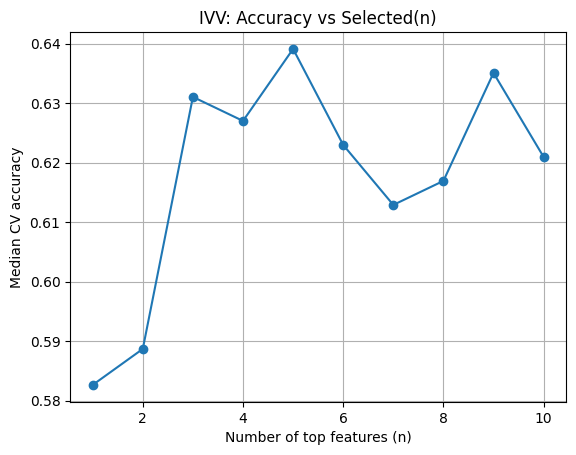

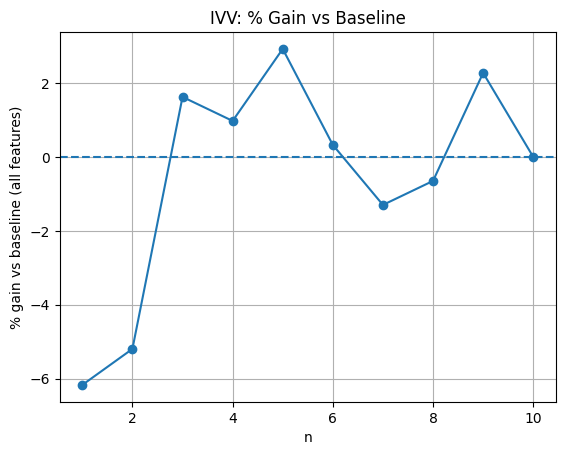

In [10]:

# -----------------------------
# 6) Plots
# -----------------------------
plt.figure()
plt.plot(tbl["n"], tbl["median_accuracy"], marker="o")
plt.xlabel("Number of top features (n)"); plt.ylabel("Median CV accuracy")
plt.title(f"{ticker}: Accuracy vs Selected(n)"); plt.grid(True); plt.show()

plt.figure()
plt.plot(tbl["n"], tbl["gain_vs_all_%"], marker="o"); plt.axhline(0, ls="--")
plt.xlabel("n"); plt.ylabel("% gain vs baseline (all features)")
plt.title(f"{ticker}: % Gain vs Baseline"); 
plt.grid(True); 
plt.show()